In [1]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
reviews = pd.read_csv("../data/raw/reviews.csv")

print("Reviews dataset loaded successfully.")
print("Shape:", reviews.shape)

Reviews dataset loaded successfully.
Shape: (5000, 5)


In [3]:
reviews.head()


,review_id,order_id,customer_id,rating,review_text
0,REV_00001,ORD_00001,CUST_0785,3,Food was okay but delivery took some time.
1,REV_00002,ORD_00002,CUST_0894,3,Food was okay but delivery took some time.
2,REV_00003,ORD_00003,CUST_0776,2,Very slow delivery and poor experience.
3,REV_00004,ORD_00004,CUST_0569,2,Food arrived late.
4,REV_00005,ORD_00005,CUST_0298,3,Average experience.


In [4]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    5000 non-null   str  
 1   order_id     5000 non-null   str  
 2   customer_id  5000 non-null   str  
 3   rating       5000 non-null   int64
 4   review_text  5000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 195.4 KB


In [5]:
print(reviews.columns.tolist())

['review_id', 'order_id', 'customer_id', 'rating', 'review_text']


In [6]:
print(reviews.isnull().sum())

review_id      0
order_id       0
customer_id    0
rating         0
review_text    0
dtype: int64


In [7]:
print(reviews["rating"].value_counts().sort_index())

rating
1     132
2     961
3    2040
4    1525
5     342
Name: count, dtype: int64


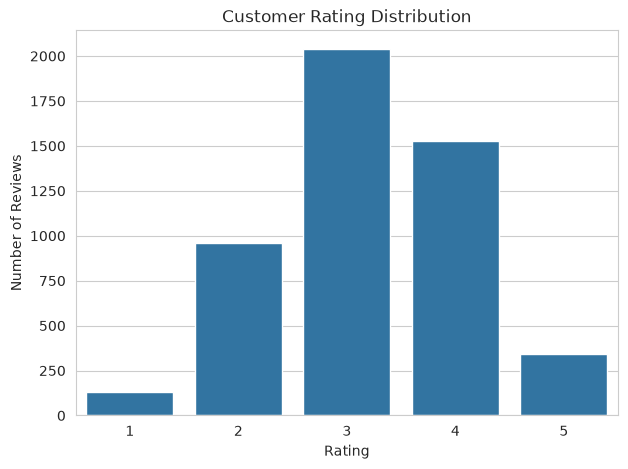

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=reviews,
    x="rating"
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [9]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /home/nineleaps/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/nineleaps/nltk_data...


True

In [10]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

print("Stop words loaded:", len(stop_words))
print("Lemmatizer initialized successfully.")

Stop words loaded: 198
Lemmatizer initialized successfully.


In [11]:
def clean_text(text):
    
    # Convert to string
    text = str(text)
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stop words
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]
    
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    
    # Join tokens back into text
    return " ".join(tokens)

In [12]:
sample_review = reviews.loc[0, "review_text"]

print("Original:")
print(sample_review)

print("\nCleaned:")
print(clean_text(sample_review))

Original:
Food was okay but delivery took some time.

Cleaned:
food okay delivery took time


In [13]:
reviews["cleaned_review"] = reviews["review_text"].apply(
    clean_text
)

reviews[
    [
        "review_text",
        "cleaned_review"
    ]
].head(10)

,review_text,cleaned_review
0,Food was okay but delivery took some time.,food okay delivery took time
1,Food was okay but delivery took some time.,food okay delivery took time
2,Very slow delivery and poor experience.,slow delivery poor experience
3,Food arrived late.,food arrived late
4,Average experience.,average experience
5,Food arrived late.,food arrived late
6,Food was okay but delivery took some time.,food okay delivery took time
7,The delivery took too long.,delivery took long
8,Food was delicious and delivery was fast.,food delicious delivery fast
9,The delivery took too long.,delivery took long


In [14]:
empty_reviews = (
    reviews["cleaned_review"]
    .str.strip()
    .eq("")
    .sum()
)

print("Empty cleaned reviews:", empty_reviews)

Empty cleaned reviews: 0


In [18]:
def rating_to_sentiment(rating):
    
    if rating <= 2:
        return "negative"
    
    elif rating == 3:
        return "neutral"
    
    else:
        return "positive"

In [19]:
reviews["sentiment"] = reviews["rating"].apply(
    rating_to_sentiment
)

reviews[
    [
        "rating",
        "sentiment",
        "review_text"
    ]
].head(10)

,rating,sentiment,review_text
0,3,neutral,Food was okay but delivery took some time.
1,3,neutral,Food was okay but delivery took some time.
2,2,negative,Very slow delivery and poor experience.
3,2,negative,Food arrived late.
4,3,neutral,Average experience.
5,1,negative,Food arrived late.
6,3,neutral,Food was okay but delivery took some time.
7,2,negative,The delivery took too long.
8,4,positive,Food was delicious and delivery was fast.
9,2,negative,The delivery took too long.


In [20]:
sentiment_counts = (
    reviews["sentiment"]
    .value_counts()
)

print(sentiment_counts)

sentiment
neutral     2040
positive    1867
negative    1093
Name: count, dtype: int64


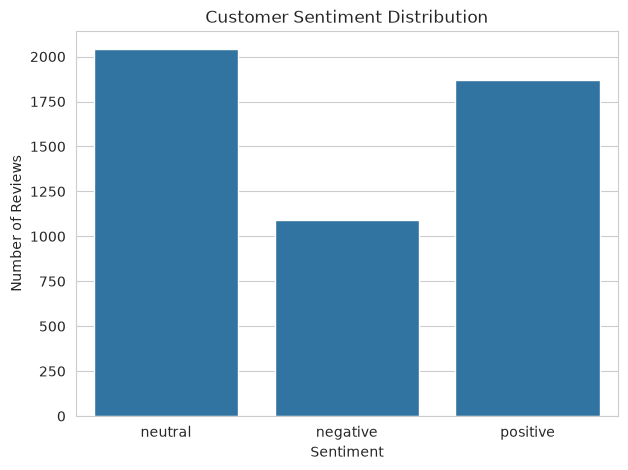

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=reviews,
    x="sentiment"
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [23]:
X = reviews["cleaned_review"]
y = reviews["sentiment"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [25]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [26]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4000, 67)
Testing TF-IDF shape: (1000, 67)


In [27]:
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of TF-IDF features: 67

First 50 features:
['acceptable' 'amazing' 'amazing experience' 'arrived' 'arrived hot'
 'arrived late' 'average' 'average experience' 'better' 'cold' 'could'
 'could better' 'decent' 'decent could' 'delayed' 'delayed food'
 'delicious' 'delicious delivery' 'delivery' 'delivery acceptable'
 'delivery fast' 'delivery late' 'delivery poor' 'delivery took'
 'excellent' 'excellent service' 'experience' 'experience food'
 'experience okay' 'fast' 'food' 'food arrived' 'food cold' 'food decent'
 'food delicious' 'food excellent' 'food hot' 'food okay' 'food quick'
 'good' 'good service' 'great' 'great food' 'hot' 'late' 'late food'
 'long' 'loved' 'loved food' 'okay']


In [28]:
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of TF-IDF features: 67

First 50 features:
['acceptable' 'amazing' 'amazing experience' 'arrived' 'arrived hot'
 'arrived late' 'average' 'average experience' 'better' 'cold' 'could'
 'could better' 'decent' 'decent could' 'delayed' 'delayed food'
 'delicious' 'delicious delivery' 'delivery' 'delivery acceptable'
 'delivery fast' 'delivery late' 'delivery poor' 'delivery took'
 'excellent' 'excellent service' 'experience' 'experience food'
 'experience okay' 'fast' 'food' 'food arrived' 'food cold' 'food decent'
 'food delicious' 'food excellent' 'food hot' 'food okay' 'food quick'
 'good' 'good service' 'great' 'great food' 'hot' 'late' 'late food'
 'long' 'loved' 'loved food' 'okay']


In [31]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [32]:
y_pred = nb_model.predict(
    X_test_tfidf
)

print("Predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.

First 20 predictions:
['positive' 'neutral' 'neutral' 'positive' 'negative' 'neutral' 'positive'
 'neutral' 'negative' 'neutral' 'negative' 'neutral' 'positive' 'positive'
 'negative' 'neutral' 'positive' 'neutral' 'negative' 'neutral']


In [33]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy, 4)
)

Accuracy: 1.0


In [34]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [35]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       219
     neutral       1.00      1.00      1.00       408
    positive       1.00      1.00      1.00       373

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



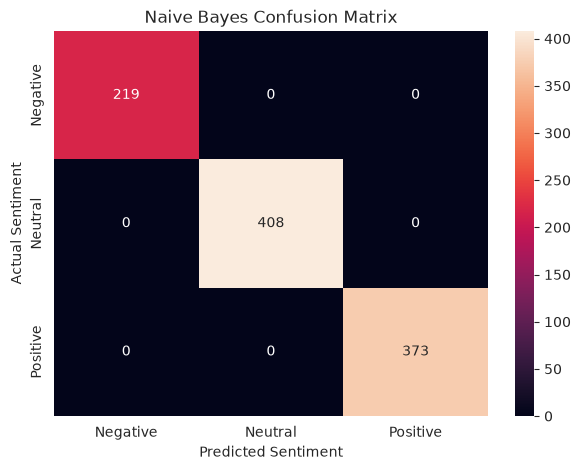

In [36]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [55]:
feature_names = tfidf.get_feature_names_out()

class_names = nb_model.classes_

print("Classes:")
print(class_names)

Classes:
['negative' 'neutral' 'positive']


In [56]:
feature_log_prob = nb_model.feature_log_prob_

for i, sentiment in enumerate(class_names):
    
    top_indices = feature_log_prob[i].argsort()[-15:][::-1]
    
    print("\n" + "=" * 50)
    print(sentiment.upper())
    print("=" * 50)
    
    for index in top_indices:
        print(feature_names[index])


NEGATIVE
late
delivery
took long
long
arrived late
food
delayed
delayed food
food hot
order
order delayed
arrived
food arrived
delivery took
took

NEUTRAL
okay
experience
experience okay
acceptable
delivery acceptable
average
average experience
delivery
decent
could
food decent
better
decent could
could better
took time

POSITIVE
food
service
fast
delivery fast
delicious
delicious delivery
food delicious
delivery
loved
loved food
food quick
quick
quick delivery
good service
good


In [57]:
keyword_results = []

for i, sentiment in enumerate(class_names):
    
    top_indices = feature_log_prob[i].argsort()[-15:][::-1]
    
    for rank, index in enumerate(top_indices, start=1):
        
        keyword_results.append({
            "sentiment": sentiment,
            "rank": rank,
            "keyword": feature_names[index],
            "score": feature_log_prob[i][index]
        })

keyword_results = pd.DataFrame(keyword_results)

keyword_results

,sentiment,rank,keyword,score
0,negative,1,late,-2.716123
1,negative,2,delivery,-2.990104
2,negative,3,took long,-3.047076
3,negative,4,long,-3.047076
4,negative,5,arrived late,-3.074233
5,negative,6,food,-3.236024
6,negative,7,delayed,-3.307602
7,negative,8,delayed food,-3.307602
8,negative,9,food hot,-3.307602
9,negative,10,order,-3.307602


In [58]:
negative_keywords = keyword_results[
    keyword_results["sentiment"] == "negative"
]

negative_keywords

,sentiment,rank,keyword,score
0,negative,1,late,-2.716123
1,negative,2,delivery,-2.990104
2,negative,3,took long,-3.047076
3,negative,4,long,-3.047076
4,negative,5,arrived late,-3.074233
5,negative,6,food,-3.236024
6,negative,7,delayed,-3.307602
7,negative,8,delayed food,-3.307602
8,negative,9,food hot,-3.307602
9,negative,10,order,-3.307602


In [59]:
positive_keywords = keyword_results[
    keyword_results["sentiment"] == "positive"
]

positive_keywords

,sentiment,rank,keyword,score
30,positive,1,food,-2.791068
31,positive,2,service,-3.001071
32,positive,3,fast,-3.334795
33,positive,4,delivery fast,-3.334795
34,positive,5,delicious,-3.334795
35,positive,6,delicious delivery,-3.334795
36,positive,7,food delicious,-3.334795
37,positive,8,delivery,-3.345804
38,positive,9,loved,-3.392745
39,positive,10,loved food,-3.392745


In [45]:
from nltk.sentiment import SentimentIntensityAnalyzer

print("VADER imported successfully.")

VADER imported successfully.


In [46]:
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [47]:
sia = SentimentIntensityAnalyzer()

print("VADER initialized successfully.")

VADER initialized successfully.


In [48]:
sample_reviews = reviews["review_text"].head(5)

for review in sample_reviews:
    
    scores = sia.polarity_scores(review)
    
    print("\nReview:")
    print(review)
    
    print("VADER scores:")
    print(scores)


Review:
Food was okay but delivery took some time.
VADER scores:
{'neg': 0.0, 'neu': 0.828, 'pos': 0.172, 'compound': 0.1154}

Review:
Food was okay but delivery took some time.
VADER scores:
{'neg': 0.0, 'neu': 0.828, 'pos': 0.172, 'compound': 0.1154}

Review:
Very slow delivery and poor experience.
VADER scores:
{'neg': 0.383, 'neu': 0.617, 'pos': 0.0, 'compound': -0.4767}

Review:
Food arrived late.
VADER scores:
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

Review:
Average experience.
VADER scores:
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


In [49]:
def vader_sentiment(text):
    
    score = sia.polarity_scores(text)["compound"]
    
    if score >= 0.05:
        return "positive"
    
    elif score <= -0.05:
        return "negative"
    
    else:
        return "neutral"

In [50]:
def vader_sentiment(text):
    
    score = sia.polarity_scores(text)["compound"]
    
    if score >= 0.05:
        return "positive"
    
    elif score <= -0.05:
        return "negative"
    
    else:
        return "neutral"

In [52]:
reviews["vader_sentiment"] = reviews["review_text"].apply(
    vader_sentiment
)

reviews[
    [
        "rating",
        "sentiment",
        "vader_sentiment",
        "review_text"
    ]
].head(10)

,rating,sentiment,vader_sentiment,review_text
0,3,neutral,positive,Food was okay but delivery took some time.
1,3,neutral,positive,Food was okay but delivery took some time.
2,2,negative,negative,Very slow delivery and poor experience.
3,2,negative,neutral,Food arrived late.
4,3,neutral,neutral,Average experience.
5,1,negative,neutral,Food arrived late.
6,3,neutral,positive,Food was okay but delivery took some time.
7,2,negative,neutral,The delivery took too long.
8,4,positive,positive,Food was delicious and delivery was fast.
9,2,negative,neutral,The delivery took too long.


In [53]:
vader_accuracy = accuracy_score(
    reviews["sentiment"],
    reviews["vader_sentiment"]
)

vader_precision = precision_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

vader_recall = recall_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

vader_f1 = f1_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

print("VADER Accuracy :", round(vader_accuracy, 4))
print("VADER Precision:", round(vader_precision, 4))
print("VADER Recall   :", round(vader_recall, 4))
print("VADER F1 Score :", round(vader_f1, 4))

VADER Accuracy : 0.5438
VADER Precision: 0.5749
VADER Recall   : 0.5438
VADER F1 Score : 0.4935


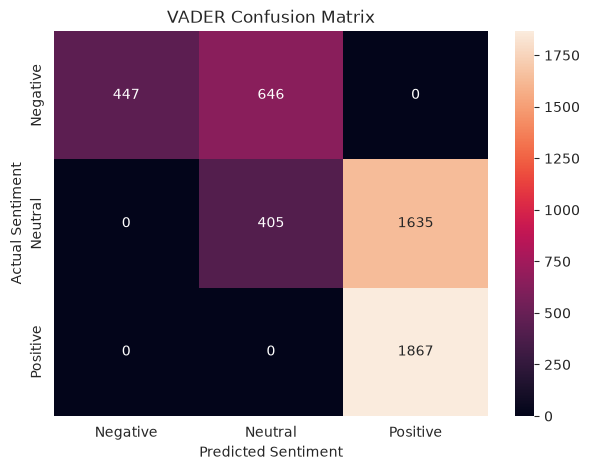

In [70]:
cm_vader = confusion_matrix(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_vader,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("VADER Confusion Matrix")

plt.show()

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "VADER"
    ],
    "Accuracy": [
        accuracy,
        vader_accuracy
    ],
    "Precision": [
        precision,
        vader_precision
    ],
    "Recall": [
        recall,
        vader_recall
    ],
    "F1 Score": [
        f1,
        vader_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,1.0000,1.00000,1.0000,1.000000
1,VADER,0.5438,0.57489,0.5438,0.493508


In [60]:
negative_keywords = keyword_results[
    keyword_results["sentiment"] == "negative"
][["rank", "keyword"]]

negative_keywords

,rank,keyword
0,1,late
1,2,delivery
2,3,took long
3,4,long
4,5,arrived late
5,6,food
6,7,delayed
7,8,delayed food
8,9,food hot
9,10,order


In [61]:
positive_keywords = keyword_results[
    keyword_results["sentiment"] == "positive"
][["rank", "keyword"]]

positive_keywords

,rank,keyword
30,1,food
31,2,service
32,3,fast
33,4,delivery fast
34,5,delicious
35,6,delicious delivery
36,7,food delicious
37,8,delivery
38,9,loved
39,10,loved food


In [62]:
negative_reviews = reviews[
    reviews["sentiment"] == "negative"
]

negative_reviews[
    ["rating", "review_text"]
].head(20)

,rating,review_text
2,2,Very slow delivery and poor experience.
3,2,Food arrived late.
5,1,Food arrived late.
7,2,The delivery took too long.
9,2,The delivery took too long.
12,2,Delivery was very late and food was cold.
16,2,The delivery took too long.
19,2,The delivery took too long.
22,2,Order was delayed and food was not hot.
32,2,Food arrived late.


In [63]:
sentiment_summary = (
    reviews["sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="review_count")
)

sentiment_summary["percentage"] = (
    sentiment_summary["review_count"]
    / sentiment_summary["review_count"].sum()
    * 100
).round(2)

sentiment_summary

,sentiment,review_count,percentage
0,neutral,2040,40.80
1,positive,1867,37.34
2,negative,1093,21.86


In [64]:
reviews.to_csv(
    "../data/processed/reviews_cleaned_sentiment.csv",
    index=False
)

print("Processed review dataset saved successfully.")

Processed review dataset saved successfully.


In [66]:
import joblib

joblib.dump(
    tfidf,
    "../outputs/models/tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


In [67]:
joblib.dump(
    nb_model,
    "../outputs/models/naive_bayes_sentiment.pkl"
)

print("Naive Bayes model saved successfully.")

Naive Bayes model saved successfully.


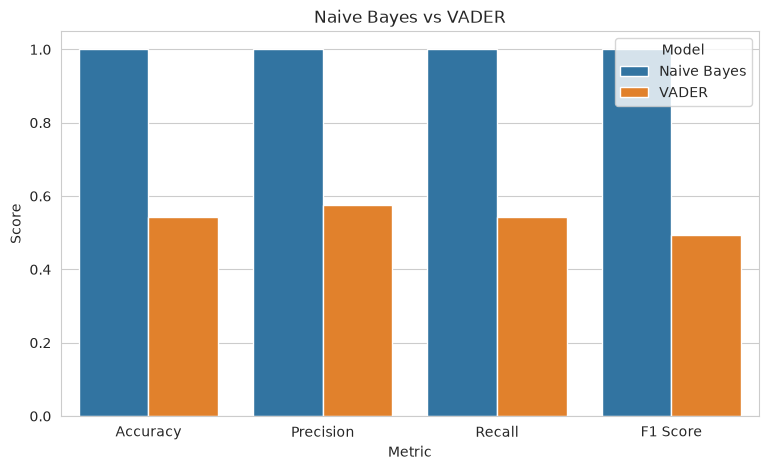

Comparison plot saved successfully.


In [69]:
comparison_plot = comparison.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_plot,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1.05)
plt.title("Naive Bayes vs VADER")

plt.savefig(
    "../outputs/plots/sentiment_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison plot saved successfully.")